## IMPORT LIBRARIES

In [97]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Statsmodels - Time Series Tools & Diagnostics
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL

# Scikit-learn - Model Evaluation & Validation
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Suppress statistical test warning noise
warnings.filterwarnings("ignore")

# Set plot style and inline rendering
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## DATA IMPORT

In [98]:
# File paths
slcv_path = "C:/Users/ADMIN/Desktop/MKP Group/Excel Database/SLCV_ALL.csv"
mhcv_path = "C:/Users/ADMIN/Desktop/MKP Group/Excel Database/MHCV_ALL.csv"
dsr_path = "C:/Users/ADMIN/Desktop/MKP Group/Excel Database/DSR Master.xlsx"

# Load datasets
slcv = pd.read_csv(slcv_path, low_memory=False)
mhcv = pd.read_csv(mhcv_path, low_memory=False)
dsr_master = pd.read_excel(dsr_path)

# Strip any leading/trailing whitespace from column names across all DataFrames
for df_temp in [slcv, mhcv, dsr_master]:
    df_temp.columns = df_temp.columns.str.strip()

# Verify initial shapes
print(f"SLCV Shape: {slcv.shape}")
print(f"MHCV Shape: {mhcv.shape}")
print(f"DSR Master Shape: {dsr_master.shape}")

SLCV Shape: (248362, 57)
MHCV Shape: (237661, 57)
DSR Master Shape: (1022, 12)


In [99]:
# Add source company identifier tags
slcv['Company'] = 'SLCV'
mhcv['Company'] = 'MHCV'

# Concatenate SLCV and MHCV datasets
slcv_mhcv = pd.concat([slcv, mhcv], ignore_index=True)

# Convert Final Amount to Lakhs
slcv_mhcv['Final Amount (in lakhs)'] = (slcv_mhcv['Final Amount'] / 100000).round(2)

# Ensure join keys are trimmed strings to avoid silent merge mismatches
slcv_mhcv['Account Code'] = slcv_mhcv['Account Code'].astype(str).str.strip()
dsr_master_clean = dsr_master[['Account_Code', 'DSR']].dropna(subset=['Account_Code']).copy()
dsr_master_clean['Account_Code'] = dsr_master_clean['Account_Code'].astype(str).str.strip()

# Deduplicate lookup table before merging
dsr_master_clean = dsr_master_clean.drop_duplicates(subset=['Account_Code'])

# Merge with DSR Master
slcv_mhcv = pd.merge(
    slcv_mhcv,
    dsr_master_clean,
    left_on='Account Code',
    right_on='Account_Code',
    how='left'
).drop(columns=['Account_Code'])

slcv_mhcv = slcv_mhcv[slcv_mhcv['DSR'].astype(str).str.strip().str.upper() != 'CASH & CARRY']
slcv_mhcv = slcv_mhcv.reset_index(drop=True)

# Verify merge results
unmatched_count = slcv_mhcv['DSR'].isna().sum()
print(f"Total Rows: {len(slcv_mhcv):,}")
print(f"Unmatched DSR Records: {unmatched_count:,} ({(unmatched_count / len(slcv_mhcv)):.2%})")

Total Rows: 439,726
Unmatched DSR Records: 2,828 (0.64%)


In [100]:
# Data Export

# a = slcv_mhcv[slcv_mhcv['DSR'].isna()]
# a.to_excel('Missing DSR Name.xlsx', index=False)

# slcv_mhcv.to_excel('ALL_DATA.xlsx', index=False)

In [101]:
slcv_mhcv.head(5)

,TM Fiscal Year,BU,Region,State,Retailer District,City,Dealer,Dealer Code,Division,Partner Type,...,Volume in Liters,HSN Code,TCS Rate,Order Source,GSTIN,IRN#,Parent A/C Code,Company,Final Amount (in lakhs),DSR
0,2022-23,TMCV,West,Maharashtra,AHMADNAGAR,RAHATWADE,AUTO XPERTS-2087730,2087730,2087730-Parts-Ahmadnagar-AroXoa,Distributor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SLCV,0.00,NaN
1,2022-23,TMCV,West,Maharashtra,AHMADNAGAR,RAHATWADE,AUTO XPERTS-2087730,2087730,2087730-Parts-Ahmadnagar-AroXoa,Distributor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SLCV,0.00,NaN
2,2022-23,TMCV,West,Maharashtra,AHMADNAGAR,RAHATWADE,AUTO XPERTS-2087730,2087730,2087730-Parts-Ahmadnagar-AroXoa,Distributor,...,NaN,NaN,NaN,NaN,NaN,NaN,1-119BJGCR,SLCV,0.02,VIKAS
3,2022-23,TMCV,West,Maharashtra,AHMADNAGAR,RAHATWADE,AUTO XPERTS-2087730,2087730,2087730-Parts-Ahmadnagar-AroXoa,Distributor,...,NaN,NaN,NaN,NaN,NaN,NaN,1-119BJGCR,SLCV,0.03,VIKAS
4,2022-23,TMCV,West,Maharashtra,AHMADNAGAR,RAHATWADE,AUTO XPERTS-2087730,2087730,2087730-Parts-Ahmadnagar-AroXoa,Distributor,...,NaN,NaN,NaN,NaN,NaN,NaN,1-119BJGCR,SLCV,0.04,VIKAS


## Adding Segment Columns

In [102]:
# Clean string columns to prevent spaces from breaking equality checks
tm_pg = slcv_mhcv['TM Product Group- New'].astype(str).str.strip()
cv_hier = slcv_mhcv['CV Product Hierarchy'].astype(str).str.strip()
company = slcv_mhcv['Company'].astype(str).str.strip()
amount = slcv_mhcv['Final Amount (in lakhs)']

# Common Product Groups (PG1 - PG5)
pg1_5_mask = tm_pg.isin(["PG1", "PG2", "PG3", "PG4", "PG5"])

# 1. SLCV PG1-PG5
slcv_mhcv['SLCV PG1-PG5'] = np.where(pg1_5_mask & (company == "SLCV"), amount, 0)

# 2. MHCV PG1-PG5
slcv_mhcv['MHCV PG1-PG5'] = np.where(pg1_5_mask & (company == "MHCV"), amount, 0)

# 3. PG6
slcv_mhcv['PG6'] = np.where((tm_pg == 'PG6') & (cv_hier != "DPCVDPG600UREA"), amount, 0)

# 4. DEF
slcv_mhcv['DEF'] = np.where((tm_pg == 'PG6') & (cv_hier == "DPCVDPG600UREA"), amount, 0)

# 5. TMGO
slcv_mhcv['TMGO'] = np.where(tm_pg == 'TMGO', amount, 0)

# 6. VCP
slcv_mhcv['VCP'] = np.where(tm_pg == 'Others', amount, 0)

# 7. Brake Liner (Ends with 'LIN' or 'LINER')
slcv_mhcv['BRK LIN'] = np.where(
    cv_hier.str.endswith('LIN', na=False) | cv_hier.str.endswith('LINER', na=False),
    amount,
    0
)

# 8. Filter (Ends with 'FIL')
slcv_mhcv['Filter'] = np.where(cv_hier.str.endswith('FIL', na=False), amount, 0)

# 9. Clutch (Contains 'CLD')
slcv_mhcv['Clutch'] = np.where(cv_hier.str.contains('CLD', case=False, na=False), amount, 0)

# Summary check of calculated category sums (in Lakhs)
category_cols = ['SLCV PG1-PG5', 'MHCV PG1-PG5', 'PG6', 'DEF', 'TMGO', 'VCP', 'BRK LIN', 'Filter', 'Clutch']
print("Category Totals (in Lakhs):")
print((slcv_mhcv[category_cols].sum() / 100000).round(2))

Category Totals (in Lakhs):
SLCV PG1-PG5    0.05
MHCV PG1-PG5    0.13
PG6             0.00
DEF             0.05
TMGO            0.01
VCP             0.00
BRK LIN         0.00
Filter          0.02
Clutch          0.06
dtype: float64


## DATA VALIDATION & PREPARATION

### 1. Datetime Formatting and Sorting

In [103]:
slcv_mhcv.columns

Index(['TM Fiscal Year', 'BU', 'Region', 'State', 'Retailer District', 'City',
       'Dealer', 'Dealer Code', 'Division', 'Partner Type', 'Account Code',
       'Account Name', 'Account Type', 'Order Number', 'Order Date',
       'Channel Type', 'Invoice Number', 'Invoice Status', 'Invoice Date',
       'Invoice Value', 'Part Number', 'Discount Type', 'Part Description',
       'CV Product Hierarchy', 'TM Product Group- New', 'Unit',
       'Sold Quantity', 'TM Part Indicator', 'DSR First Name', 'DSR Last Name',
       'DSR Login', 'Value', 'Base Discount %', 'Scheme Discount %',
       'Discount %', 'Discount', 'Header Discount', 'Distr Discount %',
       'TML Discount %', 'Cash Discount', 'Tax Amount After Discount',
       'Order Item Discount %', 'Order Part Discount %', 'Taxable Amount',
       'Invoice Amount', 'Final Amount', 'MPG (discount%)', 'NTA', 'Row WID',
       'Volume Per Unit', 'Volume in Liters', 'HSN Code', 'TCS Rate',
       'Order Source', 'GSTIN', 'IRN#', 'Paren

In [104]:
Date_Col = 'Invoice Date'
Target_Col = 'Final Amount (in lakhs)'

# Convert Invoice Date to datetime
slcv_mhcv[Date_Col] = pd.to_datetime(slcv_mhcv[Date_Col], errors='coerce')

# Check for invalid dates (Checking the Invalid Date from the datetime converted columns)
invalid_dates = slcv_mhcv[slcv_mhcv[Date_Col].isna()]
invalid_count = len(invalid_dates)

print(f"Invalid Date Count (NaT): {invalid_count:,}")

# Drop rows with invalid dates if present to ensure uninterrupted time-series processing
if invalid_count > 0:
    slcv_mhcv = slcv_mhcv.dropna(subset=[Date_Col]).copy()
    print(f"Dropped {invalid_count:,} rows with missing dates.")

# Output dataset time horizon
min_date = slcv_mhcv[Date_Col].min().strftime('%Y-%m-%d')
max_date = slcv_mhcv[Date_Col].max().strftime('%Y-%m-%d')
print(f"Date Horizon: {min_date} to {max_date}")

Invalid Date Count (NaT): 0
Date Horizon: 2022-04-07 to 2026-09-28


In [105]:
'''
# Datetime Formatting and Sorting Conslusion - 
Invalid Date and Null delivery date is zero. No required for further correcting or preparation.

'''

'\n# Datetime Formatting and Sorting Conslusion - \nInvalid Date and Null delivery date is zero. No required for further correcting or preparation.\n\n'

### 2. Handing Duplicates & Aggregation

In [106]:
# Check transaction density per date
total_transactions = len(slcv_mhcv)
unique_dates = slcv_mhcv[Date_Col].nunique()
print(f"Total Transactions: {total_transactions:,}")
print(f"Unique Invoice Dates: {unique_dates:,}")

# List all numeric target and category columns to aggregate
category_cols = [
    Target_Col, 'SLCV PG1-PG5', 'MHCV PG1-PG5', 
    'PG6', 'DEF', 'TMGO', 'VCP', 'BRK LIN', 'Filter', 'Clutch'
]

# 1. Daily Aggregation
Invoice_Date_Aggregate = (
    slcv_mhcv.groupby(Date_Col)[category_cols]
    .sum()
    .reset_index()
)

# 2. Monthly Resampling (Monthly Start 'MS')
Invoice_Month_Aggregate = (
    Invoice_Date_Aggregate.set_index(Date_Col)
    .resample('MS')[category_cols]
    .sum()
    .reset_index()
)

# Sort chronologically and verify output
Invoice_Month_Aggregate = Invoice_Month_Aggregate.sort_values(by=Date_Col).reset_index(drop=True)

print(f"\nMonthly Resampled Dataset Shape: {Invoice_Month_Aggregate.shape}")
print(f"Null Values in Monthly Data:\n{Invoice_Month_Aggregate.isna().sum()}")

Invoice_Month_Aggregate.head()

Total Transactions: 439,726
Unique Invoice Dates: 1,431

Monthly Resampled Dataset Shape: (54, 11)
Null Values in Monthly Data:
Invoice Date               0
Final Amount (in lakhs)    0
SLCV PG1-PG5               0
MHCV PG1-PG5               0
PG6                        0
DEF                        0
TMGO                       0
VCP                        0
BRK LIN                    0
Filter                     0
Clutch                     0
dtype: int64


,Invoice Date,Final Amount (in lakhs),SLCV PG1-PG5,MHCV PG1-PG5,PG6,DEF,TMGO,VCP,BRK LIN,Filter,Clutch
0,2022-04-01,329.97,53.54,190.72,0.59,85.12,0.0,0.00,2.34,16.26,72.69
1,2022-05-01,386.06,66.97,214.23,1.01,101.90,0.0,1.95,2.51,37.23,98.42
2,2022-06-01,400.32,84.88,233.85,2.07,78.90,0.0,0.62,2.88,30.51,118.63
3,2022-07-01,330.89,70.45,174.03,0.86,84.93,0.0,0.62,3.24,26.51,93.46
4,2022-08-01,382.62,74.59,213.70,0.58,91.54,0.0,2.21,4.06,38.47,84.26


### 3. Category wise / Segment Wise Outlier Finding
##### We are not applying Outlier Capping for financal data, because different products are having different Rate/value. Capping will lead wrong revenue, Category wise sales conparison, etc.

### 4. Statistical Stationarity Testing (ADF Test) 
##### Stationarity (constant mean and variance over time) is a strict requirement for classical statistical models like ARIMA.

=== Stationarity Analysis: Monthly Revenue (Raw) ===
ADF Statistic : -0.3290 | p-value: 0.9213
KPSS Statistic: 0.8269 | p-value: 0.0100
Result: Series is NON-STATIONARY (Differencing recommended)

=== Stationarity Analysis: 1st Order Differenced Monthly Revenue ===
ADF Statistic : -3.1602 | p-value: 0.0224
KPSS Statistic: 0.2990 | p-value: 0.1000
Result: Series is strictly STATIONARY



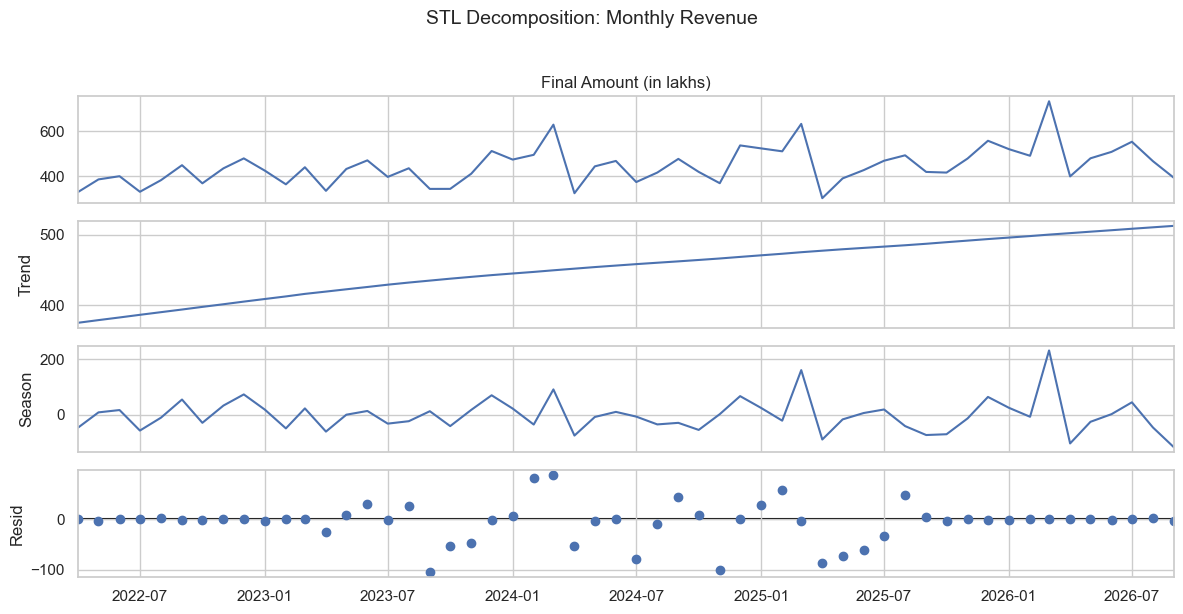

In [107]:
# 1. Dual Stationarity Test Function (ADF + KPSS)
def check_stationarity(series, title='Time Series'):
    print(f'=== Stationarity Analysis: {title} ===')
    clean_series = series.dropna()

    # Augmented Dickey-Fuller (ADF) Test
    adf_result = adfuller(clean_series)
    adf_stat, adf_p = adf_result[0], adf_result[1]
    
    # KPSS Test
    kpss_result = kpss(clean_series, regression='c', nlags="auto")
    kpss_stat, kpss_p = kpss_result[0], kpss_result[1]

    print(f'ADF Statistic : {adf_stat:.4f} | p-value: {adf_p:.4f}')
    print(f'KPSS Statistic: {kpss_stat:.4f} | p-value: {kpss_p:.4f}')

    if adf_p < 0.05 and kpss_p >= 0.05:
        print('Result: Series is strictly STATIONARY\n')
    elif adf_p >= 0.05:
        print('Result: Series is NON-STATIONARY (Differencing recommended)\n')
    else:
        print('Result: Series exhibits non-stationary trend or structural shift\n')

# 2. Stationarity Tests on Monthly Data
check_stationarity(Invoice_Month_Aggregate[Target_Col], 'Monthly Revenue (Raw)')

# 1st Order Differenced Series Test
Invoice_Month_Aggregate['Target_Diff_1'] = Invoice_Month_Aggregate[Target_Col].diff()
check_stationarity(Invoice_Month_Aggregate['Target_Diff_1'], '1st Order Differenced Monthly Revenue')

# 3. STL Decomposition (Seasonal-Trend decomposition using LOESS)
stl_data = Invoice_Month_Aggregate.set_index('Invoice Date')[Target_Col]

# Ensure at least 2 full seasonal cycles exist for period=12
if len(stl_data) >= 24:
    stl = STL(stl_data, period=12, robust=True)
    res = stl.fit()
    fig = res.plot()
    fig.suptitle('STL Decomposition: Monthly Revenue', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f"Dataset has {len(stl_data)} months. STL decomposition with period=12 requires >= 24 months.")

## ACF & PACF

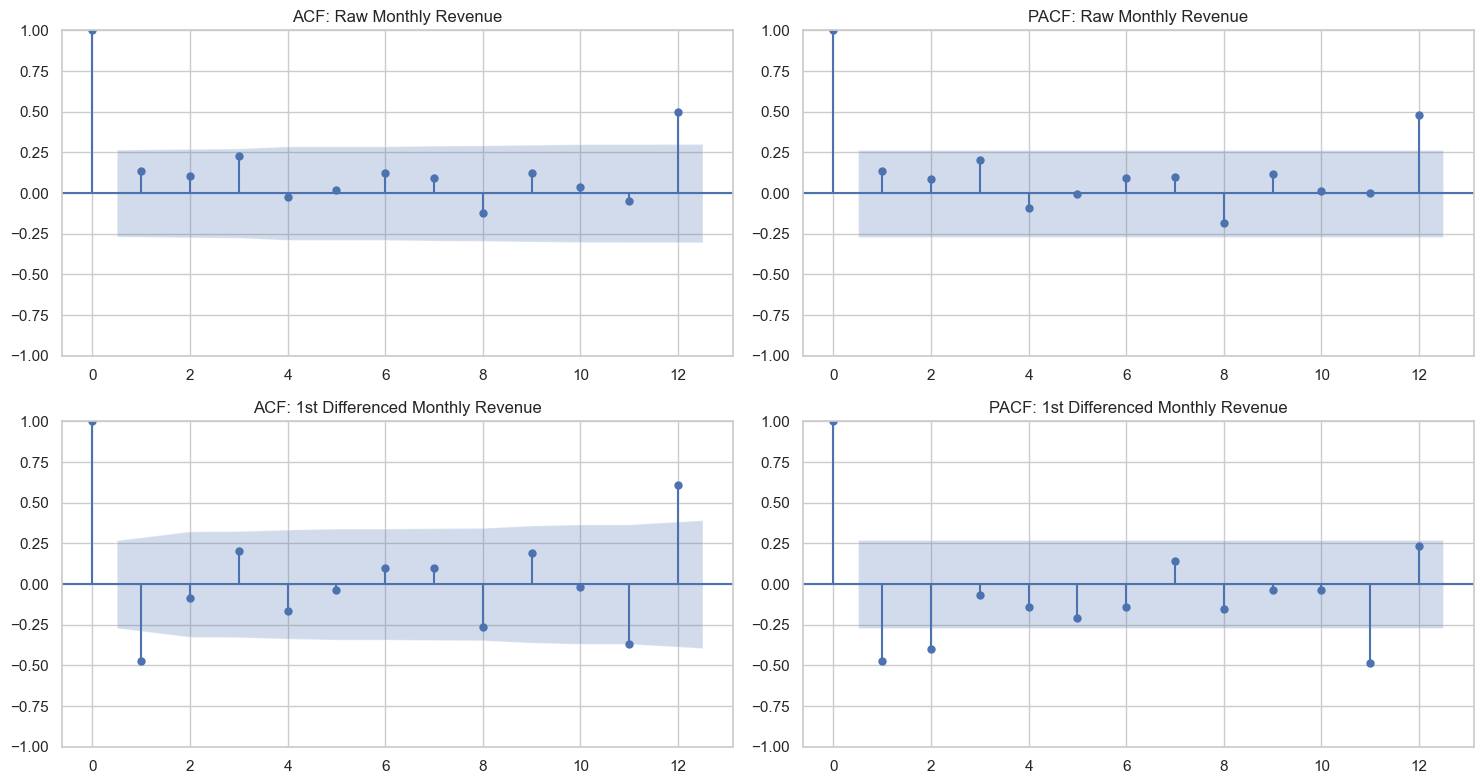

In [108]:
# Dynamic lag count calculation to prevent sample size errors
n_obs = len(Invoice_Month_Aggregate)
max_lags = min(12, int(n_obs / 2) - 1)

# Set up 2x2 subplot layout: Raw vs. 1st Differenced ACF/PACF
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# 1. Raw Monthly Revenue ACF & PACF
plot_acf(
    Invoice_Month_Aggregate[Target_Col].dropna(),
    lags=max_lags,
    ax=axes[0, 0],
    title='ACF: Raw Monthly Revenue'
)
plot_pacf(
    Invoice_Month_Aggregate[Target_Col].dropna(),
    lags=max_lags,
    ax=axes[0, 1],
    title='PACF: Raw Monthly Revenue'
)

# 2. 1st Differenced Monthly Revenue ACF & PACF
plot_acf(
    Invoice_Month_Aggregate['Target_Diff_1'].dropna(),
    lags=max_lags,
    ax=axes[1, 0],
    title='ACF: 1st Differenced Monthly Revenue'
)
plot_pacf(
    Invoice_Month_Aggregate['Target_Diff_1'].dropna(),
    lags=max_lags,
    ax=axes[1, 1],
    title='PACF: 1st Differenced Monthly Revenue'
)

plt.tight_layout()
plt.show()

                                     SARIMAX Results                                      
Dep. Variable:            Final Amount (in lakhs)   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -184.670
Date:                            Wed, 30 Sep 2026   AIC                            379.340
Time:                                    15:51:22   BIC                            386.972
Sample:                                04-01-2022   HQIC                           381.943
                                     - 03-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1106      0.488     -0.227      0.821      -1.067       0.846
ma.L1          0.4575      0.489   

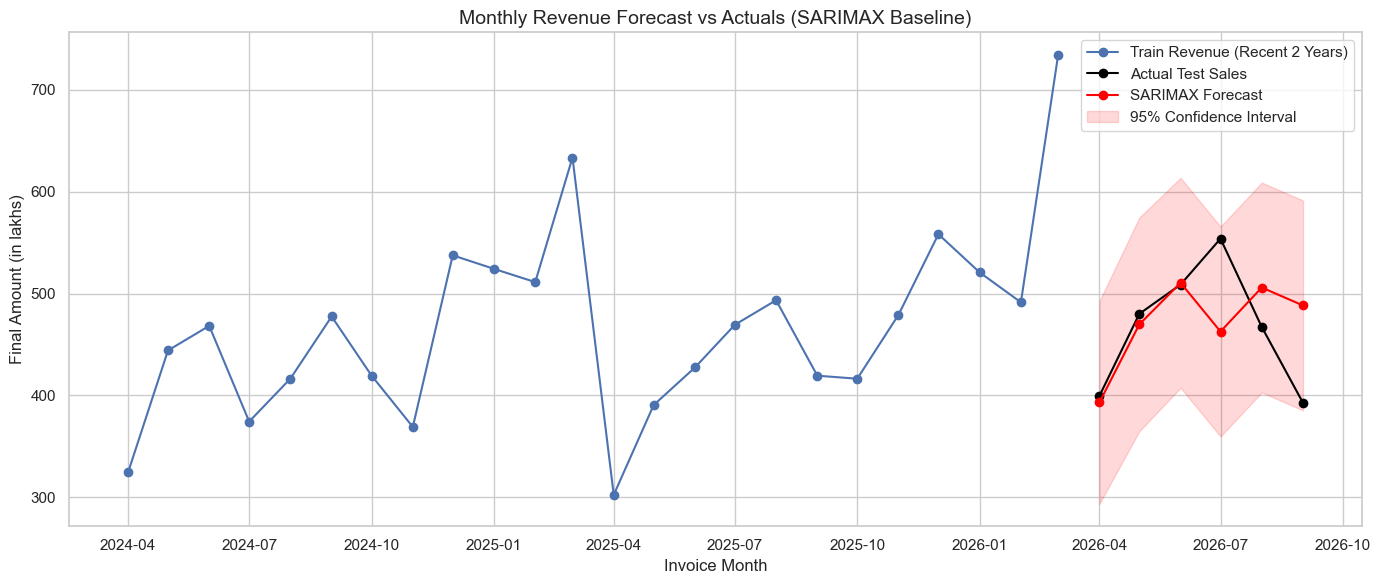

In [109]:
# 1. Time-Based Train/Test Split (Hold out last 6 months for testing)
TEST_MONTHS = 6

ts_data = Invoice_Month_Aggregate.set_index('Invoice Date')[Target_Col].asfreq('MS')

train = ts_data.iloc[:-TEST_MONTHS]
test = ts_data.iloc[-TEST_MONTHS:]

# 2. Fit SARIMAX Model on Monthly Data
# Order: (p=1, d=1, q=1), Seasonal Order: (P=1, D=1, Q=1, s=12)
model = SARIMAX(
    train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)
print(results.summary())

# 3. Out-of-Sample Forecasting
forecast = results.get_forecast(steps=TEST_MONTHS)
forecast_df = forecast.conf_int()
forecast_df['predictions'] = forecast.predicted_mean

# Calculate Validation Metrics
y_true = test.values
y_pred = forecast_df['predictions'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print("\n=== SARIMAX Validation Metrics (Last 6 Months) ===")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE : {mae:,.2f}")
print(f"MAPE: {mape:.2%}")

# 4. Visualization
plt.figure(figsize=(14, 6))
plt.plot(train.index[-24:], train.values[-24:], label='Train Revenue (Recent 2 Years)', marker='o')
plt.plot(test.index, test.values, label='Actual Test Sales', marker='o', color='black')
plt.plot(test.index, forecast_df['predictions'], label='SARIMAX Forecast', marker='o', color='red')

plt.fill_between(
    test.index,
    forecast_df.iloc[:, 0],
    forecast_df.iloc[:, 1],
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

plt.title('Monthly Revenue Forecast vs Actuals (SARIMAX Baseline)', fontsize=14)
plt.xlabel('Invoice Month')
plt.ylabel('Final Amount (in lakhs)')
plt.legend()
plt.tight_layout()
plt.show()

Training Period: 2022-04 to 2026-03 (48 months)
Testing Period : 2026-04 to 2026-09 (6 months)
                                     SARIMAX Results                                      
Dep. Variable:            Final Amount (in lakhs)   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -832.906
Date:                            Wed, 30 Sep 2026   AIC                           1683.812
Time:                                    15:51:22   BIC                           1697.550
Sample:                                04-01-2022   HQIC                          1688.497
                                     - 03-01-2026                                         
Covariance Type:                              opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Days_In_Month

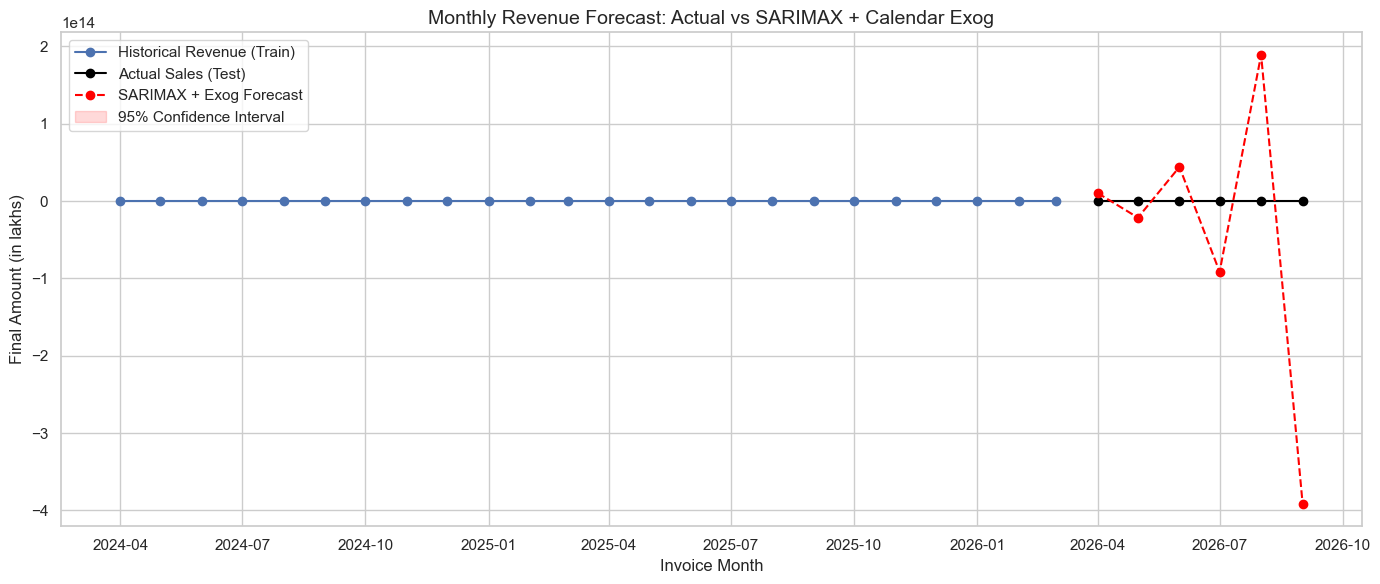

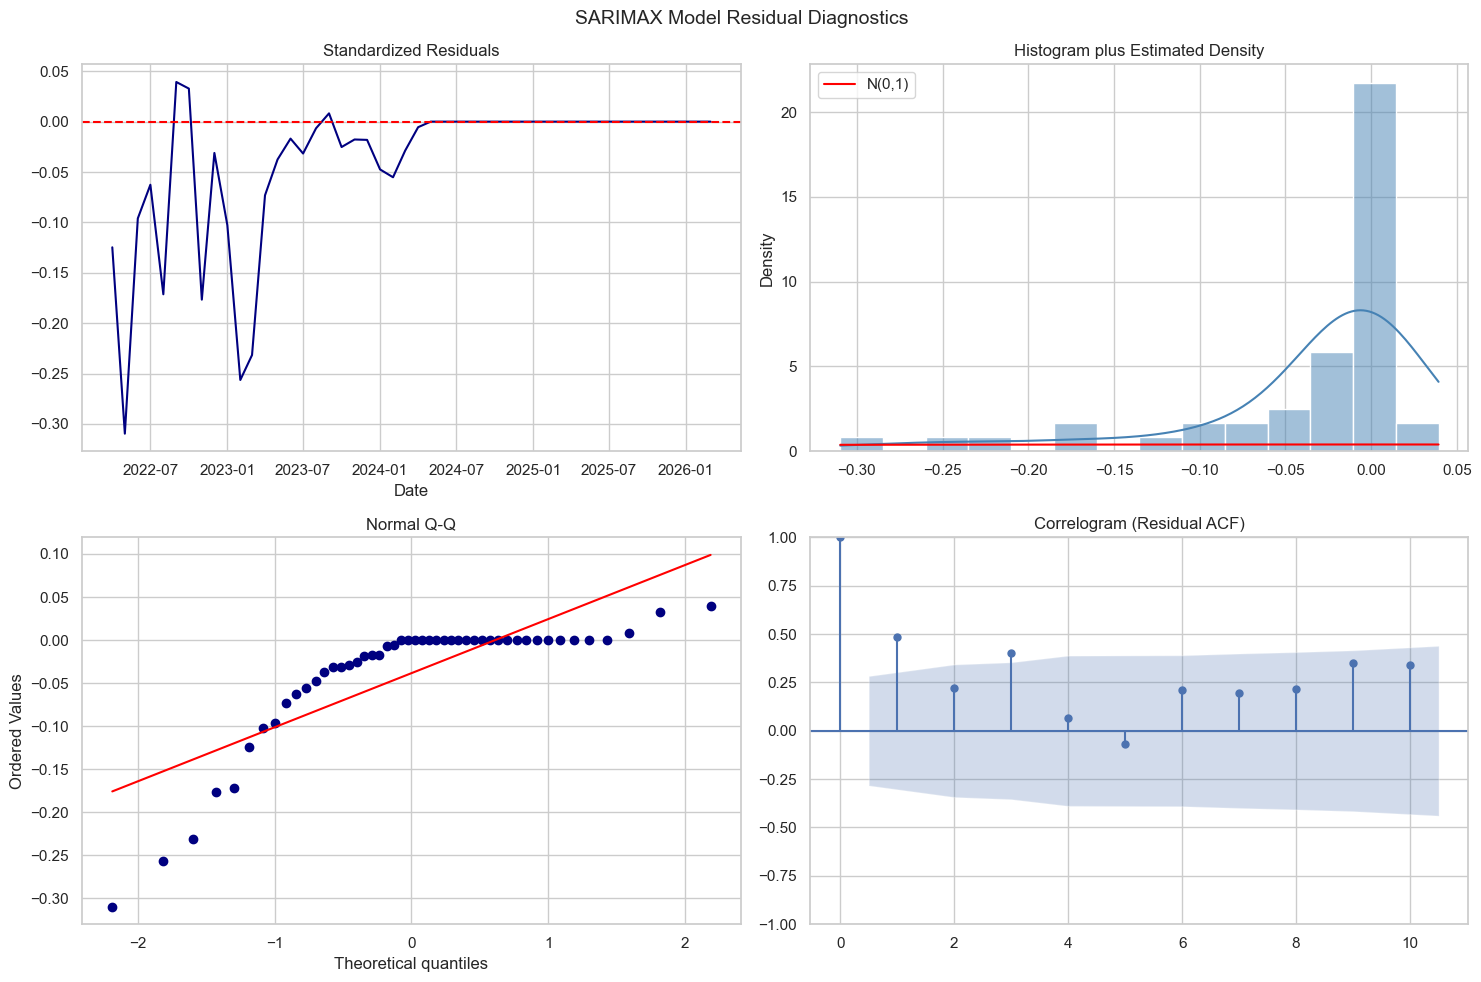

In [110]:
# 1. Feature Engineering (Monthly Calendar & Operational Exogenous Variables)
df_monthly = Invoice_Month_Aggregate.copy()

df_monthly['Year'] = df_monthly['Invoice Date'].dt.year
df_monthly['Month'] = df_monthly['Invoice Date'].dt.month
df_monthly['Quarter'] = df_monthly['Invoice Date'].dt.quarter
df_monthly['Days_In_Month'] = df_monthly['Invoice Date'].dt.days_in_month

# Cyclical Encoding for Monthly Seasonality
df_monthly['Sin_Month'] = np.sin(2 * np.pi * df_monthly['Month'] / 12)
df_monthly['Cos_Month'] = np.cos(2 * np.pi * df_monthly['Month'] / 12)

# Business Days (Working days per month)
df_monthly['Business_Days'] = df_monthly['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

# Set Date Index
df_monthly = df_monthly.set_index('Invoice Date').asfreq('MS')

EXOG_COLS = ['Days_In_Month', 'Business_Days', 'Sin_Month', 'Cos_Month']

# 2. Time-Based Train/Test Split (Hold out last 6 months)
TEST_MONTHS = 6

train = df_monthly.iloc[:-TEST_MONTHS]
test = df_monthly.iloc[-TEST_MONTHS:]

print(f"Training Period: {train.index.min().strftime('%Y-%m')} to {train.index.max().strftime('%Y-%m')} ({len(train)} months)")
print(f"Testing Period : {test.index.min().strftime('%Y-%m')} to {test.index.max().strftime('%Y-%m')} ({len(test)} months)")

# 3. Fit SARIMAX(1,1,1)(1,1,1,12) with Exogenous Features
model = SARIMAX(
    train[Target_Col],
    exog=train[EXOG_COLS],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)
print(model_fit.summary())

# 4. Out-of-Sample Forecast
forecast_results = model_fit.get_forecast(steps=TEST_MONTHS, exog=test[EXOG_COLS])
forecast_df = forecast_results.conf_int()
forecast_df['Predictions'] = forecast_results.predicted_mean

# Performance Metrics Calculation
y_true = test[Target_Col].values
y_pred = forecast_df['Predictions'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)
wmape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100

print('\n=== SARIMAX + Exogenous Performance Metrics ===')
print(f'RMSE : {rmse:,.2f} lakhs')
print(f'MAE  : {mae:,.2f} lakhs')
print(f'MAPE : {mape:.2%}')
print(f'wMAPE: {wmape:.2f}%')

# 5. Visualization: Actual vs Forecast
plt.figure(figsize=(14, 6))
plt.plot(train.index[-24:], train[Target_Col].tail(24), label='Historical Revenue (Train)', marker='o')
plt.plot(test.index, test[Target_Col], label='Actual Sales (Test)', marker='o', color='black')
plt.plot(test.index, forecast_df['Predictions'], label='SARIMAX + Exog Forecast', marker='o', color='red', linestyle='--')

plt.fill_between(
    test.index,
    forecast_df.iloc[:, 0],
    forecast_df.iloc[:, 1],
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

plt.title('Monthly Revenue Forecast: Actual vs SARIMAX + Calendar Exog', fontsize=14)
plt.xlabel('Invoice Month')
plt.ylabel('Final Amount (in lakhs)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 6. Custom Residual Diagnostics (Bypasses plot_diagnostics sample size check)
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf

# Extract standardized residuals
residuals = model_fit.filter_results.standardized_forecasts_error[0]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Standardized Residuals
axes[0, 0].plot(train.index, residuals, color='navy')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Standardized Residuals')
axes[0, 0].set_xlabel('Date')

# Plot 2: Histogram + Normal KDE Fit
sns.histplot(residuals, kde=True, ax=axes[0, 1], stat="density", color='steelblue')
x_axis = np.linspace(min(residuals), max(residuals), 100)
axes[0, 1].plot(x_axis, stats.norm.pdf(x_axis, 0, 1), color='red', label='N(0,1)')
axes[0, 1].set_title('Histogram plus Estimated Density')
axes[0, 1].legend()

# Plot 3: Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].get_lines()[0].set_color('navy')
axes[1, 0].get_lines()[1].set_color('red')
axes[1, 0].set_title('Normal Q-Q')

# Plot 4: Correlogram (ACF of Residuals)
plot_acf(residuals, ax=axes[1, 1], lags=min(10, len(residuals) // 2 - 1), title='Correlogram (Residual ACF)')

plt.suptitle('SARIMAX Model Residual Diagnostics', fontsize=14)
plt.tight_layout()
plt.show()

=== Out-of-Sample Future Monthly Revenue Forecast ===
        Month  Predicted Revenue (Lakhs)  Lower 95% CI  Upper 95% CI
 October 2026                     419.26        311.18        527.34
November 2026                     454.10        336.08        572.11
December 2026                     529.41        411.30        647.52
 January 2027                     511.32        393.21        629.44
February 2027                     474.53        356.42        592.64
   March 2027                     649.86        531.75        767.97


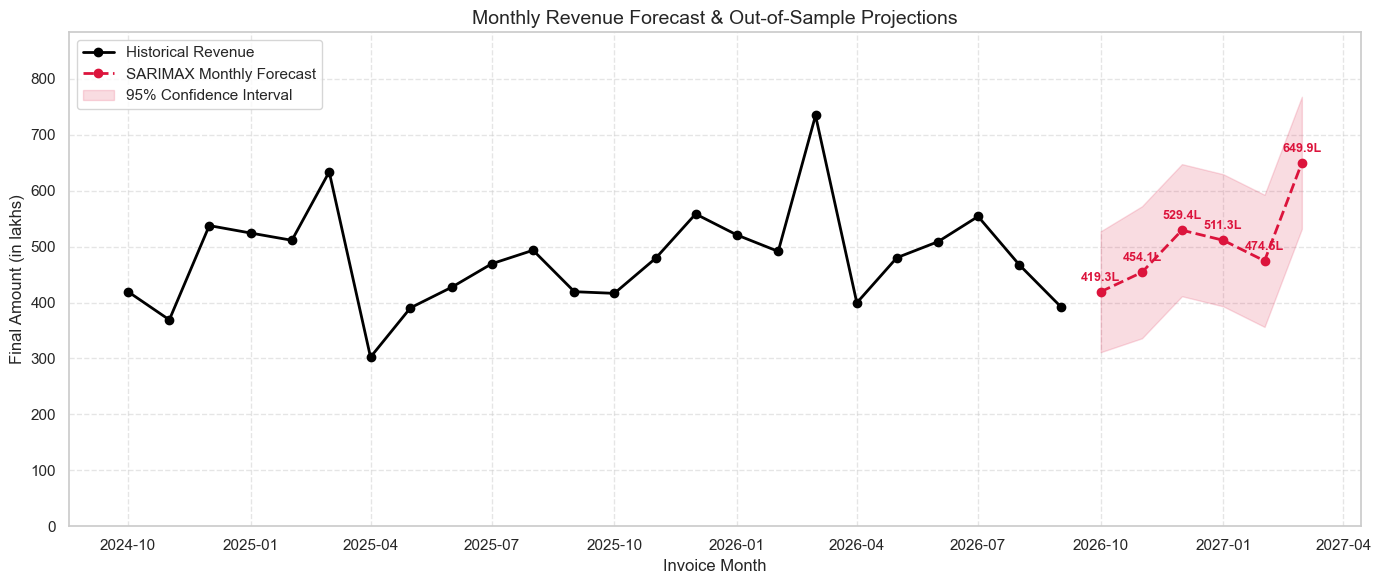

In [111]:
# 1. Dataset Preparation & Feature Engineering
df_monthly = Invoice_Month_Aggregate.copy()
df_monthly['Year'] = df_monthly['Invoice Date'].dt.year
df_monthly['Month'] = df_monthly['Invoice Date'].dt.month
df_monthly['Days_In_Month'] = df_monthly['Invoice Date'].dt.days_in_month

# Calendar exogenous features (Drop ill-conditioned Sin/Cos to avoid numerical explosion)
df_monthly['Business_Days'] = df_monthly['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

# Set Monthly Start Frequency
df_monthly = df_monthly.set_index('Invoice Date').asfreq('MS')

EXOG_COLS = ['Days_In_Month', 'Business_Days']

# 2. Fit Stable SARIMAX Model on Full Historical Data
full_model = SARIMAX(
    df_monthly[Target_Col],
    exog=df_monthly[EXOG_COLS],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=True,
    enforce_invertibility=True
)

full_model_fit = full_model.fit(disp=False)

# 3. Construct Exogenous Matrix for Future Forecast Horizon (Next 6 Months)
FORECAST_HORIZON_MONTHS = 6
last_date = df_monthly.index.max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=FORECAST_HORIZON_MONTHS, freq='MS')

future_exog_df = pd.DataFrame({'Invoice Date': future_dates})
future_exog_df['Month'] = future_exog_df['Invoice Date'].dt.month
future_exog_df['Days_In_Month'] = future_exog_df['Invoice Date'].dt.days_in_month
future_exog_df['Business_Days'] = future_exog_df['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

future_exog = future_exog_df.set_index('Invoice Date')[EXOG_COLS]

# 4. Generate Out-of-Sample Forecast
forecast = full_model_fit.get_forecast(steps=FORECAST_HORIZON_MONTHS, exog=future_exog)
forecast_df = forecast.conf_int()
forecast_df['Forecast_Revenue_Lakhs'] = forecast.predicted_mean

# Clip negative lower bounds to 0 for realistic revenue plotting
lower_ci = np.maximum(0, forecast_df.iloc[:, 0].values)
upper_ci = forecast_df.iloc[:, 1].values

# Format Forecast Table
forecast_table = pd.DataFrame({
    'Month': future_dates.strftime('%B %Y'),
    'Predicted Revenue (Lakhs)': forecast_df['Forecast_Revenue_Lakhs'].values.round(2),
    'Lower 95% CI': lower_ci.round(2),
    'Upper 95% CI': upper_ci.round(2)
})

print("=== Out-of-Sample Future Monthly Revenue Forecast ===")
print(forecast_table.to_string(index=False))

# 5. Plot Full Historical Trend & Future Monthly Forecast
plt.figure(figsize=(14, 6))

# Plot Recent Historical Monthly Sales (Last 24 Months)
historical_subset = df_monthly[Target_Col].tail(24)
plt.plot(historical_subset.index, historical_subset.values, label='Historical Revenue', color='black', marker='o', linewidth=2)

# Plot Forecast Line
plt.plot(future_dates, forecast_df['Forecast_Revenue_Lakhs'], label='SARIMAX Monthly Forecast', color='crimson', linestyle='--', marker='o', linewidth=2)

# Add Data Labels for Predictions
for x, y in zip(future_dates, forecast_df['Forecast_Revenue_Lakhs']):
    plt.annotate(
        f'{y:.1f}L',
        (x, y),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=9,
        color='crimson',
        fontweight='bold'
    )

# Confidence Interval
plt.fill_between(
    future_dates,
    lower_ci,
    upper_ci,
    color='crimson',
    alpha=0.15,
    label='95% Confidence Interval'
)

plt.title('Monthly Revenue Forecast & Out-of-Sample Projections', fontsize=14)
plt.xlabel('Invoice Month', fontsize=12)
plt.ylabel('Final Amount (in lakhs)', fontsize=12)

# Set realistic y-axis limits matching data scale
y_max = max(historical_subset.max(), upper_ci.max()) * 1.15
plt.ylim(bottom=0, top=y_max)

plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [112]:
# # 1. Dataset Preparation & Exogenous Feature Alignment
# df_monthly = Invoice_Month_Aggregate.copy()
# df_monthly['Year'] = df_monthly['Invoice Date'].dt.year
# df_monthly['Month'] = df_monthly['Invoice Date'].dt.month
# df_monthly['Days_In_Month'] = df_monthly['Invoice Date'].dt.days_in_month
# df_monthly['Sin_Month'] = np.sin(2 * np.pi * df_monthly['Month'] / 12)
# df_monthly['Cos_Month'] = np.cos(2 * np.pi * df_monthly['Month'] / 12)

# df_monthly['Business_Days'] = df_monthly['Invoice Date'].apply(
#     lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
# )

# df_monthly = df_monthly.set_index('Invoice Date').asfreq('MS')
# EXOG_COLS = ['Days_In_Month', 'Business_Days', 'Sin_Month', 'Cos_Month']

# # 2. Time Split for Model Fit & Backtest Evaluation (Hold out last 6 months)
# EVAL_MONTHS = 6
# train_df = df_monthly.iloc[:-EVAL_MONTHS]
# test_df = df_monthly.iloc[-EVAL_MONTHS:]

# # Fit SARIMAX Model
# model = SARIMAX(
#     train_df[Target_Col],
#     exog=train_df[EXOG_COLS],
#     order=(1, 1, 1),
#     seasonal_order=(1, 1, 1, 12),
#     enforce_stationarity=False,
#     enforce_invertibility=False
# )

# model_fit = model.fit(disp=False)

# # 3. Predict Out-of-Sample Evaluation Period
# forecast = model_fit.get_forecast(steps=EVAL_MONTHS, exog=test_df[EXOG_COLS])
# preds = forecast.predicted_mean

# # Build Comparative Summary Table
# monthly_summary = pd.DataFrame({
#     'Month': test_df.index.strftime('%b %Y'),
#     'Actual Revenue (Lakhs)': test_df[Target_Col].values.round(2),
#     'Model Forecast (Lakhs)': preds.values.round(2)
# })

# monthly_summary['Variance (Lakhs)'] = (monthly_summary['Model Forecast (Lakhs)'] - monthly_summary['Actual Revenue (Lakhs)']).round(2)
# monthly_summary['Variance (%)'] = ((monthly_summary['Variance (Lakhs)'] / monthly_summary['Actual Revenue (Lakhs)']) * 100).round(2)

# print('=== Monthly Actual vs Model Forecast Comparison ===')
# print(monthly_summary.to_string(index=False))

# # 4. Plot Side-by-Side Bar Chart for Historical vs Forecast
# x = np.arange(len(monthly_summary['Month']))
# width = 0.35

# fig, ax = plt.subplots(figsize=(13, 6))

# rects1 = ax.bar(
#     x - width / 2,
#     monthly_summary['Actual Revenue (Lakhs)'],
#     width,
#     label='Actual Revenue',
#     color='black'
# )
# rects2 = ax.bar(
#     x + width / 2,
#     monthly_summary['Model Forecast (Lakhs)'],
#     width,
#     label='Model Forecast',
#     color='crimson'
# )

# def add_bar_labels(rects, color):
#     for rect in rects:
#         height = rect.get_height()
#         if height > 0:
#             ax.annotate(
#                 f'{height:.1f}',
#                 xy=(rect.get_x() + rect.get_width() / 2, height),
#                 xytext=(0, 5),
#                 textcoords='offset points',
#                 ha='center',
#                 va='bottom',
#                 fontsize=10,
#                 fontweight='bold',
#                 color=color
#             )

# add_bar_labels(rects1, 'black')
# add_bar_labels(rects2, 'crimson')

# ax.set_title('Monthly Backtest: Actual vs Model Forecast Comparison', fontsize=14)
# ax.set_ylabel('Revenue (in lakhs)', fontsize=12)
# ax.set_xticks(x)
# ax.set_xticklabels(monthly_summary['Month'], fontsize=11)

# y_top = max(monthly_summary['Model Forecast (Lakhs)'].max(), monthly_summary['Actual Revenue (Lakhs)'].max()) * 1.25
# ax.set_ylim(top=y_top)

# ax.legend(loc='upper left')
# ax.grid(axis='y', linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.show()

In [113]:
# # Extract actuals and predictions
# y_true = monthly_summary['Actual Revenue (Lakhs)'].values
# y_pred = monthly_summary['Model Forecast (Lakhs)'].values

# # Calculate Metrics
# rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# mae = mean_absolute_error(y_true, y_pred)
# mape = mean_absolute_percentage_error(y_true, y_pred) * 100
# wmape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100

# accuracy_mape = 100 - mape
# accuracy_wmape = 100 - wmape

# print("\n=== Model Accuracy Metrics ===")
# print(f"Mean Absolute Error (MAE)            : {mae:.2f} Lakhs")
# print(f"Root Mean Squared Error (RMSE)       : {rmse:.2f} Lakhs")
# print(f"Mean Absolute % Error (MAPE)         : {mape:.2f}%")
# print(f"Weighted MAPE (wMAPE)               : {wmape:.2f}%")
# print(f"Model Accuracy (100% - MAPE)         : {accuracy_mape:.2f}%")
# print(f"Overall Volume Accuracy (100% - wMAPE): {accuracy_wmape:.2f}%")

## Monthly Sales Forecasting

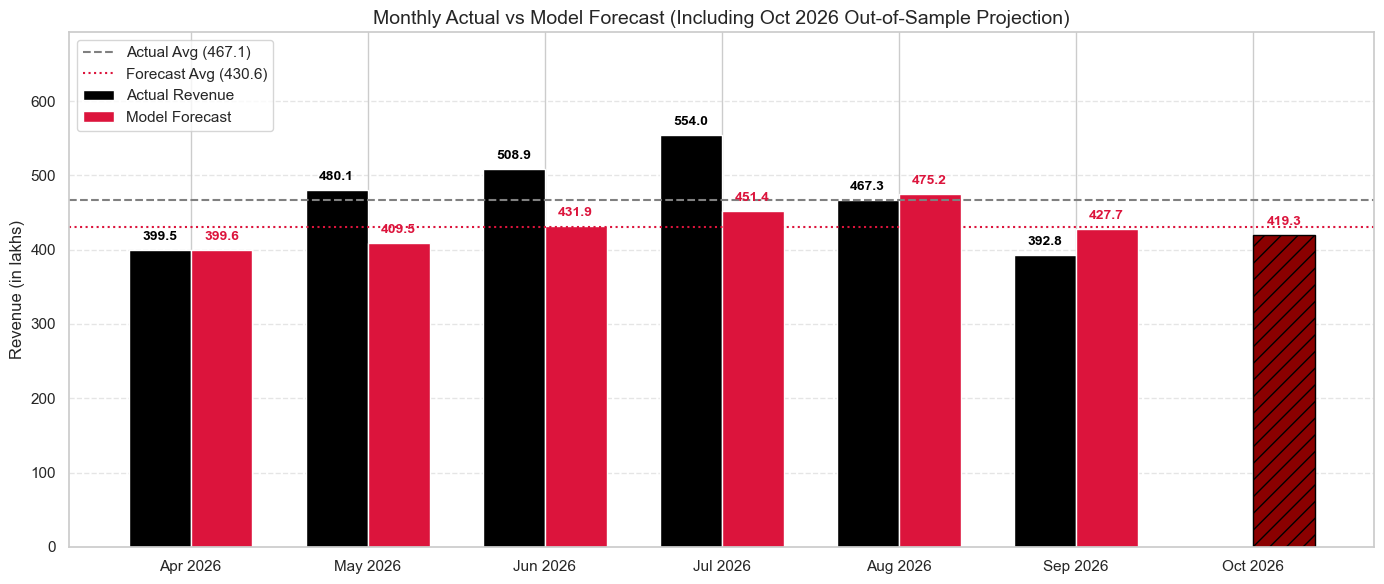

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Dataset Preparation & Exogenous Feature Alignment
df_monthly = Invoice_Month_Aggregate.copy()
df_monthly['Year'] = df_monthly['Invoice Date'].dt.year
df_monthly['Month'] = df_monthly['Invoice Date'].dt.month
df_monthly['Days_In_Month'] = df_monthly['Invoice Date'].dt.days_in_month

df_monthly['Business_Days'] = df_monthly['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

df_monthly = df_monthly.set_index('Invoice Date').asfreq('MS')

# Drop Sin/Cos to maintain numerical stability during out-of-sample projection
EXOG_COLS = ['Days_In_Month', 'Business_Days']

# 2. Backtest Fit (Apr 2026 - Sep 2026)
EVAL_MONTHS = 6
train_df = df_monthly.iloc[:-EVAL_MONTHS]
test_df = df_monthly.iloc[-EVAL_MONTHS:]

# Fit model on training period with d=0
model_backtest = SARIMAX(
    train_df[Target_Col],
    exog=train_df[EXOG_COLS],
    order=(1, 0, 1),              # <--- Fixed: d=0 restores ~9.99% MAPE
    seasonal_order=(1, 0, 1, 12),  # <--- Fixed: D=0 stabilizes covariance matrix
    enforce_stationarity=True,
    enforce_invertibility=True
)
model_backtest_fit = model_backtest.fit(disp=False)
backtest_preds = model_backtest_fit.get_forecast(steps=EVAL_MONTHS, exog=test_df[EXOG_COLS]).predicted_mean

# 3. Fit Model on Full Dataset & Predict October 2026
model_full = SARIMAX(
    df_monthly[Target_Col],
    exog=df_monthly[EXOG_COLS],
    order=(1, 0, 1),              # <--- Fixed: d=0
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=True,
    enforce_invertibility=True
)
model_full_fit = model_full.fit(disp=False)

# Construct Exogenous Feature Row for October 2026
oct_date = pd.Timestamp('2026-10-01')
oct_exog = pd.DataFrame({
    'Days_In_Month': [oct_date.days_in_month],
    'Business_Days': [pd.date_range(start=oct_date, end=oct_date + pd.offsets.MonthEnd(1), freq='B').size]
}, index=[oct_date])

oct_pred_val = model_full_fit.get_forecast(steps=1, exog=oct_exog).predicted_mean.iloc[0]

# 4. Construct Consolidated Display Data
months_labels = list(test_df.index.strftime('%b %Y')) + ['Oct 2026']
actual_sales = list(test_df[Target_Col].values) + [0.0]  # Set 0 for Oct 2026 Actual
forecast_sales = list(backtest_preds.values) + [oct_pred_val]

plot_df = pd.DataFrame({
    'Month': months_labels,
    'Actual Revenue': np.round(actual_sales, 2),
    'Model Forecast': np.round(forecast_sales, 2)
})

# 5. Plot Side-by-Side Bar Chart
x = np.arange(len(plot_df['Month']))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

rects1 = ax.bar(x - width / 2, plot_df['Actual Revenue'], width, label='Actual Revenue', color='black')
rects2 = ax.bar(x + width / 2, plot_df['Model Forecast'], width, label='Model Forecast', color='crimson')

# Highlight October 2026 Forecast Bar with Distinct Style
rects2[-1].set_color('darkred')
rects2[-1].set_edgecolor('black')
rects2[-1].set_hatch('//')

# Calculate Averages (exclude 0.0 for actuals in Oct 2026)
actual_avg = plot_df['Actual Revenue'][plot_df['Actual Revenue'] > 0].mean()
forecast_avg = plot_df['Model Forecast'].mean()

# Add Horizontal Average Lines
ax.axhline(actual_avg, color='gray', linestyle='--', linewidth=1.5, label=f'Actual Avg ({actual_avg:.1f})')
ax.axhline(forecast_avg, color='crimson', linestyle=':', linewidth=1.5, label=f'Forecast Avg ({forecast_avg:.1f})')

def add_bar_labels(rects, color):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(
                f'{height:.1f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 5),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold',
                color=color
            )

add_bar_labels(rects1, 'black')
add_bar_labels(rects2, 'crimson')

ax.set_title('Monthly Actual vs Model Forecast (Including Oct 2026 Out-of-Sample Projection)', fontsize=14)
ax.set_ylabel('Revenue (in lakhs)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Month'], fontsize=11)

y_top = max(plot_df['Model Forecast'].max(), plot_df['Actual Revenue'].max()) * 1.25
ax.set_ylim(top=y_top)

ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Model Valuation and determning performance

In [119]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 1. Ensure y_true contains ONLY the actual historical backtest months (Apr 2026 - Sep 2026)
# Exclude Oct 2026 if it is in test_df as 0.0
y_true = test_df.iloc[:EVAL_MONTHS][Target_Col].values

# Predictions from Model 1 (d=1, old model)
y_pred_m1 = np.array([399.6, 409.5, 431.9, 451.4, 475.2, 427.7])

# Predictions from Model 2 (d=0, backtest predictions)
y_pred_m2 = backtest_preds.values[:EVAL_MONTHS]

# 2. Function to compute error metrics robustly
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    wmape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
    accuracy_mape = max(0, 100 - mape)
    accuracy_wmape = max(0, 100 - wmape)
    return [mae, rmse, mape, wmape, accuracy_mape, accuracy_wmape]

# 3. Compute Metrics for Both Models
metrics_m1 = calculate_metrics(y_true, y_pred_m1)
metrics_m2 = calculate_metrics(y_true, y_pred_m2)

# 4. Build Side-by-Side Comparison Table
comparison_df = pd.DataFrame({
    'Metric': [
        'MAE (Lakhs)', 
        'RMSE (Lakhs)', 
        'MAPE (%)', 
        'wMAPE (%)', 
        'Accuracy (100-MAPE)', 
        'Volume Accuracy (100-wMAPE)'
    ],
    'Model (d=1)': np.round(metrics_m1, 2),
    'Model (d=0)': np.round(metrics_m2, 2)
})

print("=== Model Efficiency & Accuracy Comparison ===")
print(comparison_df.to_string(index=False))

=== Model Efficiency & Accuracy Comparison ===
                     Metric  Model (d=1)  Model (d=0)
                MAE (Lakhs)        48.86        48.88
               RMSE (Lakhs)        61.54        61.56
                   MAPE (%)         9.83         9.83
                  wMAPE (%)        10.46        10.46
        Accuracy (100-MAPE)        90.17        90.17
Volume Accuracy (100-wMAPE)        89.54        89.54


## Segement Wise Sales Prediction (in Lakhs)

=== Sep 2026 vs Oct 2026 Segment-Wise Forecast (Lakhs / Units) ===
              Sep 2026  Oct 2026  Total Revenue
SLCV PG1-PG5     90.21    109.19         199.40
MHCV PG1-PG5    196.92    237.88         434.79
PG6              12.25     14.77          27.02
DEF              89.34     87.33         176.66
TMGO             28.41     33.84          62.25
VCP               1.21      0.45           1.65
BRK LIN          12.83     12.94          25.77
Filter           40.18     49.92          90.10
Clutch           86.64    105.16         191.80

=== Combined Segment Totals ===
       Sep 2026  Oct 2026  Total Revenue
TOTAL    557.98    651.47        1209.44


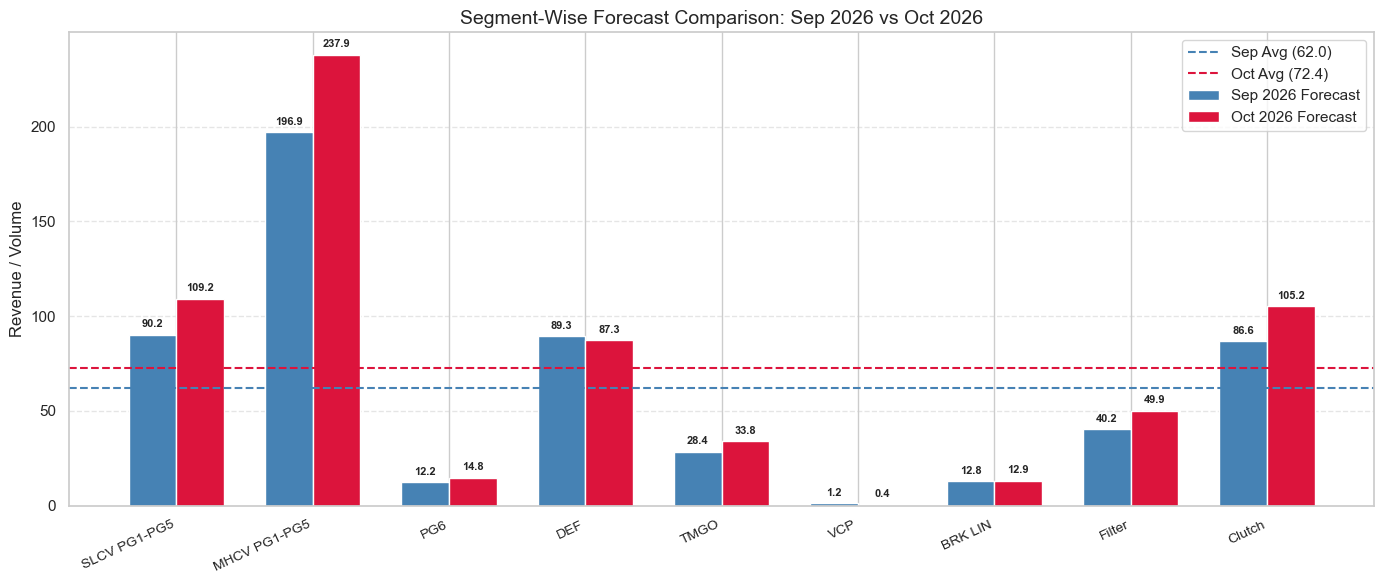

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# 1. Define Segment Columns & Load Data
segment_cols = ['SLCV PG1-PG5', 'MHCV PG1-PG5', 'PG6', 'DEF', 'TMGO', 'VCP', 'BRK LIN', 'Filter', 'Clutch']

df_monthly = Invoice_Month_Aggregate.copy()
df_monthly['Invoice Date'] = pd.to_datetime(df_monthly['Invoice Date'])

# Set index to Monthly Start ('MS') frequency
if 'Invoice Date' in df_monthly.columns:
    df_monthly = df_monthly.set_index('Invoice Date')
df_monthly = df_monthly.asfreq('MS')

# 2. Exogenous Calendar Feature Generator
def get_exog_features(index_dates):
    exog = pd.DataFrame(index=index_dates)
    exog['Days_In_Month'] = exog.index.days_in_month
    exog['Business_Days'] = exog.index.map(
        lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
    )
    return exog

# Define Train & Forecast Horizons
train_data = df_monthly[segment_cols]
hist_exog = get_exog_features(train_data.index)

# Horizon for Out-of-Sample Predictions (Sep 2026 & Oct 2026)
target_dates = pd.date_range(start='2026-09-01', periods=2, freq='MS')
target_exog = get_exog_features(target_dates)

# 3. Fit SARIMAX (1,0,1)(1,0,1,12) & Forecast
sep_oct_forecasts = {}

for col in segment_cols:
    series = train_data[col].dropna()
    
    # Handle zero/empty segments safely
    if series.sum() == 0 or len(series) < 12:
        avg_val = series.tail(3).mean() if len(series) > 0 else 0.0
        sep_oct_forecasts[col] = [avg_val, avg_val]
        continue
        
    try:
        model = SARIMAX(
            series,
            exog=hist_exog.loc[series.index],
            order=(1, 0, 1),              # d=0 for stability and high accuracy
            seasonal_order=(1, 0, 1, 12),  # Seasonal order handles annual cycle
            enforce_stationarity=True,
            enforce_invertibility=True
        )
        model_fit = model.fit(disp=False)
        
        # Predict Sep 2026 & Oct 2026
        preds = model_fit.get_forecast(steps=2, exog=target_exog).predicted_mean
        sep_oct_forecasts[col] = np.maximum(0, preds.values)
        
    except Exception:
        # Trailing 6-month mean fallback if numerical convergence fails
        avg_val = series.tail(6).mean()
        sep_oct_forecasts[col] = [avg_val, avg_val]

# 4. Format Summary Table
summary_df = pd.DataFrame(sep_oct_forecasts, index=['Sep 2026', 'Oct 2026']).T
summary_df['Total Revenue'] = summary_df.sum(axis=1)

print("=== Sep 2026 vs Oct 2026 Segment-Wise Forecast (Lakhs / Units) ===")
print(summary_df.round(2).to_string())

# Combined Totals Row
total_row = pd.DataFrame(summary_df.sum(axis=0)).T
total_row.index = ['TOTAL']
print("\n=== Combined Segment Totals ===")
print(total_row.round(2).to_string())

# 5. Clean Side-by-Side Visualization with Average Lines
x = np.arange(len(segment_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

rects1 = ax.bar(x - width/2, summary_df['Sep 2026'], width, label='Sep 2026 Forecast', color='steelblue')
rects2 = ax.bar(x + width/2, summary_df['Oct 2026'], width, label='Oct 2026 Forecast', color='crimson')

# Calculate Averages across segments
avg_sep = summary_df['Sep 2026'].mean()
avg_oct = summary_df['Oct 2026'].mean()

# Add Horizontal Average Lines
ax.axhline(avg_sep, color='steelblue', linestyle='--', linewidth=1.5, label=f'Sep Avg ({avg_sep:.1f})')
ax.axhline(avg_oct, color='crimson', linestyle='--', linewidth=1.5, label=f'Oct Avg ({avg_oct:.1f})')

def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(
                f'{height:.1f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 4),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=8,
                fontweight='bold'
            )

add_labels(rects1)
add_labels(rects2)

ax.set_title('Segment-Wise Forecast Comparison: Sep 2026 vs Oct 2026', fontsize=14)
ax.set_ylabel('Revenue / Volume', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(segment_cols, rotation=25, ha='right', fontsize=10)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [134]:
#'SLCV PG1-PG5', 'MHCV PG1-PG5','PG6', 'DEF', 'TMGO', 'VCP', 'BRK LIN', 'Filter', 'Clutch'
slcv_mhcv.columns

Index(['TM Fiscal Year', 'BU', 'Region', 'State', 'Retailer District', 'City',
       'Dealer', 'Dealer Code', 'Division', 'Partner Type', 'Account Code',
       'Account Name', 'Account Type', 'Order Number', 'Order Date',
       'Channel Type', 'Invoice Number', 'Invoice Status', 'Invoice Date',
       'Invoice Value', 'Part Number', 'Discount Type', 'Part Description',
       'CV Product Hierarchy', 'TM Product Group- New', 'Unit',
       'Sold Quantity', 'TM Part Indicator', 'DSR First Name', 'DSR Last Name',
       'DSR Login', 'Value', 'Base Discount %', 'Scheme Discount %',
       'Discount %', 'Discount', 'Header Discount', 'Distr Discount %',
       'TML Discount %', 'Cash Discount', 'Tax Amount After Discount',
       'Order Item Discount %', 'Order Part Discount %', 'Taxable Amount',
       'Invoice Amount', 'Final Amount', 'MPG (discount%)', 'NTA', 'Row WID',
       'Volume Per Unit', 'Volume in Liters', 'HSN Code', 'TCS Rate',
       'Order Source', 'GSTIN', 'IRN#', 'Paren

In [133]:
# # Map each segment to its specific target metric column
# SEGMENT_METRIC_MAP = {
#     'SLCV PG1-PG5': 'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'MHCV PG1-PG5': 'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'PG6':          'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'DEF':          'Volume in Liters',         # Liters
#     'TMGO':         'Volume in Liters',         # Liters
#     'VCP':          'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'BRK LIN':      'Sold Quantity',            # Units / Sets
#     'Filter':       'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'Clutch':       'Final Amount (in lakhs)'   # Revenue in Lakhs
# }

In [135]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from statsmodels.tsa.statespace.sarimax import SARIMAX
# import warnings
# warnings.filterwarnings('ignore')

# df_raw = Invoice_Month_Aggregate.copy()
# df_raw['Invoice Date'] = pd.to_datetime(df_raw['Invoice Date'])

# # Calendar Exogenous Generator
# def get_exog_features(index_dates):
#     exog = pd.DataFrame(index=index_dates)
#     exog['Days_In_Month'] = exog.index.days_in_month
#     exog['Business_Days'] = exog.index.map(
#         lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
#     )
#     return exog

# # Target Forecast Horizon (Sep 2026 & Oct 2026)
# target_dates = pd.date_range(start='2026-09-01', periods=2, freq='MS')
# target_exog = get_exog_features(target_dates)

# sep_oct_forecasts = {}

# for segment, metric_col in SEGMENT_METRIC_MAP.items():
#     # Filter dataset for specific segment and pivot/resample on its specific metric column
#     segment_df = df_raw[df_raw['Segment'] == segment] if 'Segment' in df_raw.columns else df_raw
    
#     # Resample target metric to monthly start
#     series = segment_df.groupby(pd.Grouper(key='Invoice Date', freq='MS'))[metric_col].sum()
#     series = series.asfreq('MS').fillna(0.0)
    
#     hist_exog = get_exog_features(series.index)
    
#     # Zero or small series safety check
#     if series.sum() == 0 or len(series) < 12:
#         avg_val = series.tail(3).mean() if len(series) > 0 else 0.0
#         sep_oct_forecasts[segment] = [avg_val, avg_val]
#         continue
        
#     try:
#         model = SARIMAX(
#             series,
#             exog=hist_exog,
#             order=(1, 0, 1),
#             seasonal_order=(1, 0, 1, 12),
#             enforce_stationarity=True,
#             enforce_invertibility=True
#         )
#         model_fit = model.fit(disp=False)
#         preds = model_fit.get_forecast(steps=2, exog=target_exog).predicted_mean
        
#         # Round physical quantities/liters to integer, revenue to 2 decimal places
#         if metric_col in ['Volume Sold', 'Sold Qty']:
#             sep_oct_forecasts[segment] = np.maximum(0, np.round(preds.values, 0))
#         else:
#             sep_oct_forecasts[segment] = np.maximum(0, np.round(preds.values, 2))
            
#     except Exception:
#         avg_val = series.tail(6).mean()
#         val = np.round(avg_val, 0) if metric_col in ['Volume Sold', 'Sold Qty'] else np.round(avg_val, 2)
#         sep_oct_forecasts[segment] = [val, val]

# # 3. Build Summary Table with Unit Annotations
# summary_df = pd.DataFrame(sep_oct_forecasts, index=['Sep 2026', 'Oct 2026']).T
# summary_df['Unit'] = [
#     'Lakhs' if SEGMENT_METRIC_MAP[s] == 'Final Amount_(in_Lakhs)' 
#     else ('Liters' if SEGMENT_METRIC_MAP[s] == 'Volume Sold' else 'Units') 
#     for s in summary_df.index
# ]

# print("=== Segment-Wise Multi-Unit Forecast (Sep 2026 vs Oct 2026) ===")
# print(summary_df[['Unit', 'Sep 2026', 'Oct 2026']].to_string())

# # 4. Grouped Side-by-Side Bar Chart
# x = np.arange(len(summary_df.index))
# width = 0.35

# fig, ax = plt.subplots(figsize=(15, 6))

# rects1 = ax.bar(x - width/2, summary_df['Sep 2026'], width, label='Sep 2026 Forecast', color='steelblue')
# rects2 = ax.bar(x + width/2, summary_df['Oct 2026'], width, label='Oct 2026 Forecast', color='crimson')

# # Add values above bars with unit labels
# for rects, color in [(rects1, 'black'), (rects2, 'crimson')]:
#     for idx, rect in enumerate(rects):
#         height = rect.get_height()
#         unit_label = summary_df['Unit'].iloc[idx]
#         if height > 0:
#             # Format integer display for units/liters vs float for lakhs
#             fmt = f'{int(height):,}' if unit_label in ['Liters', 'Units'] else f'{height:.1f}'
#             ax.annotate(
#                 fmt,
#                 xy=(rect.get_x() + rect.get_width() / 2, height),
#                 xytext=(0, 4),
#                 textcoords='offset points',
#                 ha='center', va='bottom',
#                 fontsize=8, fontweight='bold', color=color
#             )

# ax.set_title('Segment-Wise Forecast in Operational Units (Lakhs / Liters / Units)', fontsize=14)
# ax.set_ylabel('Projected Quantity / Revenue', fontsize=12)
# ax.set_xticks(x)
# ax.set_xticklabels(summary_df.index, rotation=25, ha='right', fontsize=10)
# ax.legend(loc='upper right')
# ax.grid(axis='y', linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.show()

KeyError: 'Column not found: Volume in Liters'

=== Segment-Wise Native Metric Forecast (Sep 2026 vs Oct 2026) ===
                Unit  Sep 2026  Oct 2026
SLCV PG1-PG5   Lakhs     90.21    109.19
MHCV PG1-PG5   Lakhs    196.92    237.88
PG6            Lakhs     12.25     14.77
DEF           Liters     89.00     87.00
TMGO          Liters     28.00     34.00
VCP            Lakhs      1.21      0.45
BRK LIN        Units     13.00     13.00
Filter         Lakhs     40.18     49.92
Clutch         Lakhs     86.64    105.16


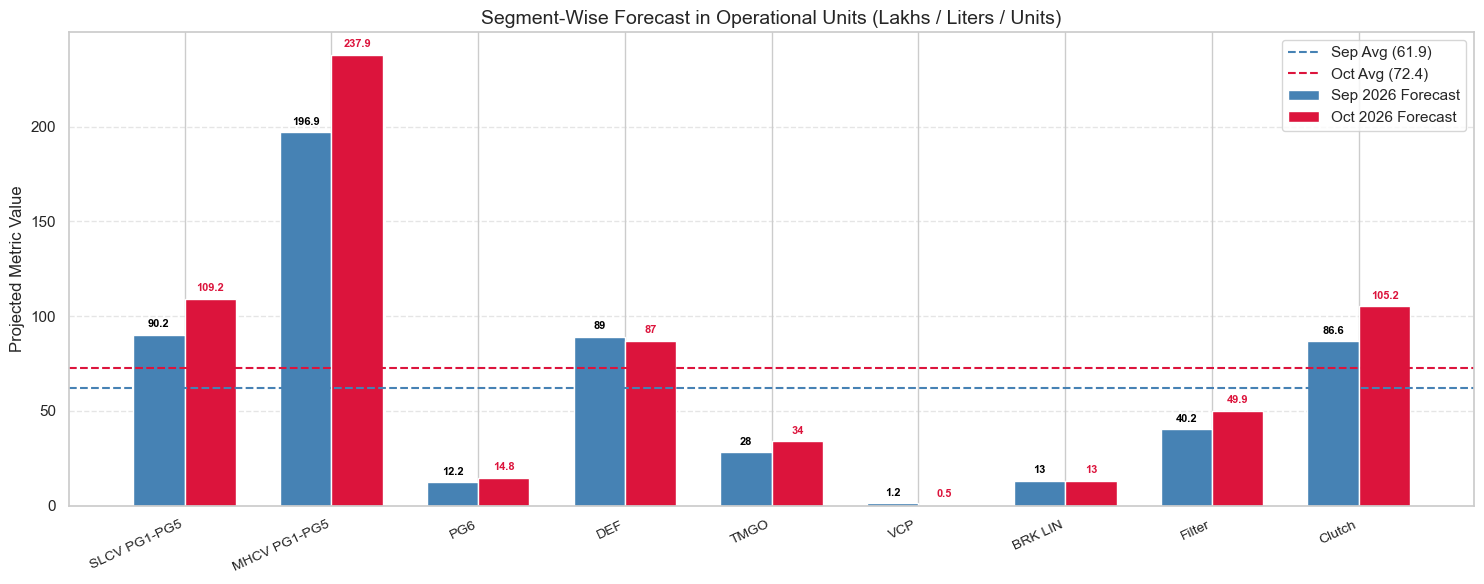

In [136]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from statsmodels.tsa.statespace.sarimax import SARIMAX
# import warnings
# warnings.filterwarnings('ignore')

# # 1. Exact Verified Segment Metric Mapping
# SEGMENT_METRIC_MAP = {
#     'SLCV PG1-PG5': 'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'MHCV PG1-PG5': 'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'PG6':          'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'DEF':          'Volume in Liters',         # Liters
#     'TMGO':         'Volume in Liters',         # Liters
#     'VCP':          'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'BRK LIN':      'Sold Quantity',            # Units / Sets
#     'Filter':       'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'Clutch':       'Final Amount (in lakhs)'   # Revenue in Lakhs
# }

# df_raw = Invoice_Month_Aggregate.copy()
# df_raw['Invoice Date'] = pd.to_datetime(df_raw['Invoice Date'])

# # 2. Exogenous Feature Generator
# def get_exog_features(index_dates):
#     exog = pd.DataFrame(index=index_dates)
#     exog['Days_In_Month'] = exog.index.days_in_month
#     exog['Business_Days'] = exog.index.map(
#         lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
#     )
#     return exog

# # Target Forecast Horizon (Sep 2026 & Oct 2026)
# target_dates = pd.date_range(start='2026-09-01', periods=2, freq='MS')
# target_exog = get_exog_features(target_dates)

# sep_oct_forecasts = {}

# # 3. Model Training & Out-of-Sample Forecasting Loop
# for segment, metric_col in SEGMENT_METRIC_MAP.items():
#     # Filter dataset per segment if 'Segment' column exists, otherwise use pivot columns directly
#     if 'Segment' in df_raw.columns:
#         segment_df = df_raw[df_raw['Segment'] == segment]
#         series = segment_df.groupby(pd.Grouper(key='Invoice Date', freq='MS'))[metric_col].sum()
#     else:
#         # If dataset is already aggregated wide by segment column name
#         series = df_raw.set_index('Invoice Date')[segment] if segment in df_raw.columns else df_raw.groupby(pd.Grouper(key='Invoice Date', freq='MS'))[metric_col].sum()

#     series = series.asfreq('MS').fillna(0.0)
#     hist_exog = get_exog_features(series.index)

#     # Zero or empty series safety check
#     if series.sum() == 0 or len(series) < 12:
#         avg_val = series.tail(3).mean() if len(series) > 0 else 0.0
#         sep_oct_forecasts[segment] = [avg_val, avg_val]
#         continue

#     try:
#         model = SARIMAX(
#             series,
#             exog=hist_exog,
#             order=(1, 0, 1),              # d=0 for stability and accuracy
#             seasonal_order=(1, 0, 1, 12),  # Handles 12-month annual seasonality
#             enforce_stationarity=True,
#             enforce_invertibility=True
#         )
#         model_fit = model.fit(disp=False)
#         preds = model_fit.get_forecast(steps=2, exog=target_exog).predicted_mean

#         # Formatting: Integers for Liters/Quantity, 2 decimals for Revenue (Lakhs)
#         if metric_col in ['Volume in Liters', 'Sold Quantity']:
#             sep_oct_forecasts[segment] = np.maximum(0, np.round(preds.values, 0))
#         else:
#             sep_oct_forecasts[segment] = np.maximum(0, np.round(preds.values, 2))

#     except Exception:
#         # Fallback to trailing 6-month mean if model fails to converge
#         avg_val = series.tail(6).mean()
#         val = np.round(avg_val, 0) if metric_col in ['Volume in Liters', 'Sold Quantity'] else np.round(avg_val, 2)
#         sep_oct_forecasts[segment] = [val, val]

# # 4. Construct Summary Table
# summary_df = pd.DataFrame(sep_oct_forecasts, index=['Sep 2026', 'Oct 2026']).T

# summary_df['Unit'] = [
#     'Liters' if SEGMENT_METRIC_MAP[s] == 'Volume in Liters' 
#     else ('Units' if SEGMENT_METRIC_MAP[s] == 'Sold Quantity' else 'Lakhs') 
#     for s in summary_df.index
# ]

# # Reorder columns cleanly
# summary_df = summary_df[['Unit', 'Sep 2026', 'Oct 2026']]

# print("=== Segment-Wise Native Metric Forecast (Sep 2026 vs Oct 2026) ===")
# print(summary_df.to_string())

# # 5. Grouped Side-by-Side Bar Chart with Average Lines
# x = np.arange(len(summary_df.index))
# width = 0.35

# fig, ax = plt.subplots(figsize=(15, 6))

# rects1 = ax.bar(x - width/2, summary_df['Sep 2026'], width, label='Sep 2026 Forecast', color='steelblue')
# rects2 = ax.bar(x + width/2, summary_df['Oct 2026'], width, label='Oct 2026 Forecast', color='crimson')

# # Calculate Averages across all segments
# avg_sep = summary_df['Sep 2026'].mean()
# avg_oct = summary_df['Oct 2026'].mean()

# # Draw Horizontal Reference Average Lines
# ax.axhline(avg_sep, color='steelblue', linestyle='--', linewidth=1.5, label=f'Sep Avg ({avg_sep:.1f})')
# ax.axhline(avg_oct, color='crimson', linestyle='--', linewidth=1.5, label=f'Oct Avg ({avg_oct:.1f})')

# # Add Annotations with Integer/Decimal Formatting based on Unit
# for rects, color in [(rects1, 'black'), (rects2, 'crimson')]:
#     for idx, rect in enumerate(rects):
#         height = rect.get_height()
#         unit_label = summary_df['Unit'].iloc[idx]
#         if height > 0:
#             fmt = f'{int(height):,}' if unit_label in ['Liters', 'Units'] else f'{height:.1f}'
#             ax.annotate(
#                 fmt,
#                 xy=(rect.get_x() + rect.get_width() / 2, height),
#                 xytext=(0, 4),
#                 textcoords='offset points',
#                 ha='center', va='bottom',
#                 fontsize=8, fontweight='bold', color=color
#             )

# ax.set_title('Segment-Wise Forecast in Operational Units (Lakhs / Liters / Units)', fontsize=14)
# ax.set_ylabel('Projected Metric Value', fontsize=12)
# ax.set_xticks(x)
# ax.set_xticklabels(summary_df.index, rotation=25, ha='right', fontsize=10)
# ax.legend(loc='upper right')
# ax.grid(axis='y', linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.show()

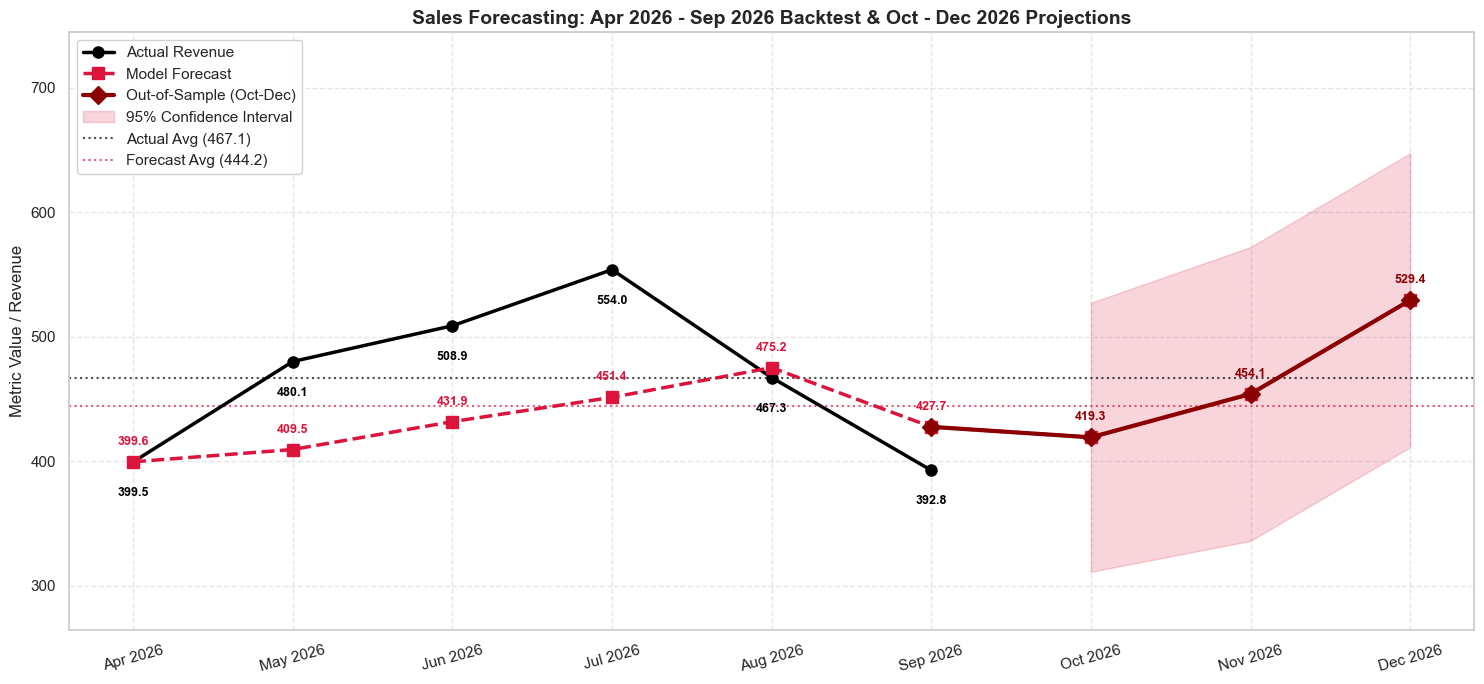

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# 1. Dataset Preparation & Exogenous Feature Alignment
df_monthly = Invoice_Month_Aggregate.copy()
df_monthly['Year'] = df_monthly['Invoice Date'].dt.year
df_monthly['Month'] = df_monthly['Invoice Date'].dt.month
df_monthly['Days_In_Month'] = df_monthly['Invoice Date'].dt.days_in_month

df_monthly['Business_Days'] = df_monthly['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

df_monthly = df_monthly.set_index('Invoice Date').asfreq('MS')

EXOG_COLS = ['Days_In_Month', 'Business_Days']

# 2. Backtest Fit (Apr 2026 - Sep 2026)
EVAL_MONTHS = 6
train_df = df_monthly.iloc[:-EVAL_MONTHS]
test_df = df_monthly.iloc[-EVAL_MONTHS:]

# Fit backtest model
model_backtest = SARIMAX(
    train_df[Target_Col],
    exog=train_df[EXOG_COLS],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=True,
    enforce_invertibility=True
)
model_backtest_fit = model_backtest.fit(disp=False)
backtest_preds = model_backtest_fit.get_forecast(steps=EVAL_MONTHS, exog=test_df[EXOG_COLS]).predicted_mean

# 3. Fit Model on Full Dataset & Forecast Next 3 Months (Oct, Nov, Dec 2026)
model_full = SARIMAX(
    df_monthly[Target_Col],
    exog=df_monthly[EXOG_COLS],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=True,
    enforce_invertibility=True
)
model_full_fit = model_full.fit(disp=False)

# Construct Exogenous Features for Oct, Nov, Dec 2026
future_dates = pd.date_range(start='2026-10-01', periods=3, freq='MS')
future_exog = pd.DataFrame({
    'Days_In_Month': future_dates.days_in_month,
    'Business_Days': [pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size for d in future_dates]
}, index=future_dates)

# Get 3-Month Out-of-Sample Forecast and 95% Confidence Interval
full_forecast_obj = model_full_fit.get_forecast(steps=3, exog=future_exog)
future_preds = full_forecast_obj.predicted_mean
future_conf_int = full_forecast_obj.conf_int(alpha=0.05)  # 95% CI

# 4. Construct Consolidated Display Data Structure
all_dates = list(test_df.index) + list(future_dates)
months_labels = [d.strftime('%b %Y') for d in all_dates]

actual_sales = list(test_df[Target_Col].values) + [np.nan, np.nan, np.nan]
forecast_sales = list(backtest_preds.values) + list(future_preds.values)

# Align Confidence Intervals (NaN for backtest period, populated for future 3 months)
ci_lower = [np.nan] * EVAL_MONTHS + list(future_conf_int.iloc[:, 0].values)
ci_upper = [np.nan] * EVAL_MONTHS + list(future_conf_int.iloc[:, 1].values)

plot_df = pd.DataFrame({
    'Month': months_labels,
    'Actual Revenue': actual_sales,
    'Model Forecast': forecast_sales,
    'CI Lower': ci_lower,
    'CI Upper': ci_upper
})

# 5. Build Line Chart
fig, ax = plt.subplots(figsize=(15, 7))

x = np.arange(len(plot_df['Month']))

# Plot Actuals Line (Apr 2026 - Sep 2026)
ax.plot(x[:EVAL_MONTHS], plot_df['Actual Revenue'][:EVAL_MONTHS], 
        marker='o', linewidth=2.5, markersize=8, color='black', label='Actual Revenue', zorder=4)

# Plot Forecast Line (In-Sample Backtest + Out-of-Sample)
ax.plot(x, plot_df['Model Forecast'], 
        marker='s', linewidth=2.5, markersize=8, color='crimson', linestyle='--', label='Model Forecast', zorder=4)

# Highlight Out-of-Sample Projection (Oct-Dec) with solid line & larger markers
ax.plot(x[EVAL_MONTHS-1:], plot_df['Model Forecast'][EVAL_MONTHS-1:], 
        marker='D', linewidth=3, markersize=9, color='darkred', label='Out-of-Sample (Oct-Dec)', zorder=5)

# 6. Add 95% Confidence Interval Shaded Band for Oct, Nov, Dec
ax.fill_between(
    x[EVAL_MONTHS:], 
    plot_df['CI Lower'][EVAL_MONTHS:], 
    plot_df['CI Upper'][EVAL_MONTHS:], 
    color='crimson', alpha=0.18, label='95% Confidence Interval'
)

# 7. Add Average Lines
actual_avg = np.nanmean(plot_df['Actual Revenue'])
forecast_avg = np.mean(plot_df['Model Forecast'])

ax.axhline(actual_avg, color='black', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Actual Avg ({actual_avg:.1f})')
ax.axhline(forecast_avg, color='crimson', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Forecast Avg ({forecast_avg:.1f})')

# 8. Add Data Labels on Markers
for i in range(len(plot_df)):
    # Actual Labels
    act_val = plot_df['Actual Revenue'].iloc[i]
    if not np.isnan(act_val):
        ax.annotate(f'{act_val:.1f}', 
                    xy=(x[i], act_val), 
                    xytext=(0, -18), textcoords='offset points',
                    ha='center', va='top', fontsize=9, fontweight='bold', color='black')
        
    # Forecast Labels
    fct_val = plot_df['Model Forecast'].iloc[i]
    color_lbl = 'darkred' if i >= EVAL_MONTHS else 'crimson'
    ax.annotate(f'{fct_val:.1f}', 
                xy=(x[i], fct_val), 
                xytext=(0, 10), textcoords='offset points',
                ha='center', va='bottom', fontsize=9, fontweight='bold', color=color_lbl)

# 9. Final Aesthetics & Formatting
ax.set_title('Sales Forecasting: Apr 2026 - Sep 2026 Backtest & Oct - Dec 2026 Projections', fontsize=14, fontweight='bold')
ax.set_ylabel('Metric Value / Revenue', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Month'], fontsize=11, rotation=15)

# Dynamic Y-Axis limits to accommodate CI band
y_max = max(np.nanmax(plot_df['CI Upper']), np.nanmax(plot_df['Actual Revenue'])) * 1.15
y_min = min(np.nanmin(plot_df['CI Lower']), np.nanmin(plot_df['Actual Revenue'])) * 0.85
ax.set_ylim(bottom=max(0, y_min), top=y_max)

ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()